# Week 7 Lab: Cross-Validation — sklearn and From Scratch

**CS 203 — Software Tools and Techniques for AI**

Prof. Nipun Batra, IIT Gandhinagar

---

**Goal:** Implement every CV strategy from the lecture **twice** — once with sklearn (2 lines), then from scratch (to understand what's really happening).

**Structure:**
| Part | CV Strategy | sklearn | From Scratch |
|------|-----------|---------|-------------|
| 0 | Setup + Dataset | — | — |
| 1 | Train/Test Split | `train_test_split` | Manual index splitting |
| 2 | K-Fold CV | `KFold` | Loop + index partitioning |
| 3 | Stratified K-Fold | `StratifiedKFold` | Round-robin by class |
| 4 | Time Series Split | `TimeSeriesSplit` | Expanding window |
| 5 | Group K-Fold | `GroupKFold` | Group-aware splitting |
| 6 | LOSO | `LeaveOneGroupOut` | Leave-one-subject-out |
| 7 | Model Comparison | Putting it all together | — |

**How to use this lab:** Each part has:
- 🟢 **sklearn version** — run it, understand the output
- 🔨 **From-scratch version** — fill in the `# TODO` cells, verify your output matches sklearn

## Part 0: Setup + Dataset

We'll use a simple dataset throughout: **study hours → exam pass/fail** (same as lecture slides).

Dataset: 200 samples, 98 pass (49%), 102 fail (51%)
X shape: (200, 1), y shape: (200,)


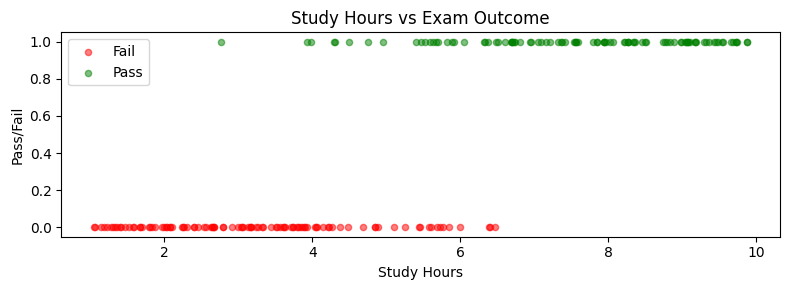

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    TimeSeriesSplit, GroupKFold, LeaveOneGroupOut,
    cross_val_score
)

np.random.seed(42)

# --- Dataset: study hours vs exam pass/fail ---
N = 200
hours = np.random.uniform(1, 10, N)
noise = np.random.normal(0, 1.5, N)
pass_fail = (hours + noise > 5.5).astype(int)

X = hours.reshape(-1, 1)
y = pass_fail

print(f"Dataset: {N} samples, {y.sum()} pass ({y.mean():.0%}), {N - y.sum()} fail ({1-y.mean():.0%})")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Quick visualization
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(X[y==0], y[y==0], alpha=0.5, label="Fail", c="red", s=20)
ax.scatter(X[y==1], y[y==1], alpha=0.5, label="Pass", c="green", s=20)
ax.set_xlabel("Study Hours")
ax.set_ylabel("Pass/Fail")
ax.legend()
ax.set_title("Study Hours vs Exam Outcome")
plt.tight_layout()
plt.show()

---

## Part 1: Train/Test Split

**Lecture slide reference:** Section 2 — "The simplest evaluation strategy"

**Why?** We need held-out data to estimate generalization. Training accuracy measures memorization, not generalization.

### 🟢 sklearn version

In [2]:
# sklearn: one line
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train acc: {model.score(X_train, y_train):.3f}")
print(f"Test acc:  {model.score(X_test, y_test):.3f}")

Train size: 160, Test size: 40
Train acc: 0.925
Test acc:  0.900


### 🔨 From scratch

**Hints:**
1. Create an array of indices `[0, 1, 2, ..., N-1]`
2. Shuffle them (use `np.random.RandomState(42)` to match sklearn's seed)
3. Split at position `int(N * 0.8)`
4. Use the indices to slice `X` and `y`

In [3]:
# TODO: Implement train/test split from scratch
# Your output should match the sklearn version above

def my_train_test_split(X, y, test_size=0.2, random_state=42):
    """Split X, y into train and test sets.

    Steps:
    1. Create indices array
    2. Shuffle with the given random_state
    3. Compute the split point
    4. Return X_train, X_test, y_train, y_test
    """
    pass

# Test it
X_tr, X_te, y_tr, y_te = my_train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_tr)}, Test size: {len(X_te)}")

TypeError: cannot unpack non-iterable NoneType object

**🤔 Discussion:** Run the sklearn split with 5 different `random_state` values. How much does the test accuracy vary? (This motivates cross-validation!)

---

## Part 2: K-Fold Cross-Validation

**Lecture slide reference:** Section 5 — "Use ALL data for both training and validation"

**Key idea:** Split data into K folds. Each fold takes a turn as the validation set. Average the K scores.

### 🟢 sklearn version

In [ ]:
# sklearn KFold — explicit version (so we can see the folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
scores = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X)):
    model.fit(X[train_idx], y[train_idx])
    score = model.score(X[val_idx], y[val_idx])
    scores.append(score)
    print(f"Fold {fold_num}: train={len(train_idx)}, val={len(val_idx)}, acc={score:.3f}")

print(f"\nMean: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

In [ ]:
# Even shorter: cross_val_score does the loop for you
scores_quick = cross_val_score(
    DecisionTreeClassifier(max_depth=3, random_state=42),
    X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
print(f"cross_val_score: {scores_quick}")
print(f"Mean: {scores_quick.mean():.3f} ± {scores_quick.std():.3f}")

### 🔨 From scratch

**Hints:**
1. Shuffle indices, then split into K roughly equal chunks using `np.array_split`
2. For each fold `k`: the validation set is `folds[k]`, training set is everything else
3. Use `np.concatenate([folds[j] for j in range(K) if j != k])` to build the training indices
4. Train a fresh model on the training indices, score on the validation indices
5. Collect all K scores, compute mean ± std

In [ ]:
# TODO: Implement K-Fold CV from scratch

def my_kfold_cv(X, y, model_class, model_params, K=5, random_state=42):
    """Run K-Fold cross-validation from scratch.

    Returns: list of K accuracy scores

    Steps:
    1. Create and shuffle indices
    2. Split into K chunks (np.array_split)
    3. Loop: for each fold, build train/val indices, fit, score
    """
    n = len(X)
    indices = np.arange(0, n)
    np.random.RandomState(random_state).shuffle(indices)


    pass

# Test it — should match the sklearn output above
scores_scratch = my_kfold_cv(X, y, DecisionTreeClassifier, {"max_depth": 3, "random_state": 42})
print(f"From scratch: {[f'{s:.3f}' for s in scores_scratch]}")
print(f"Mean: {np.mean(scores_scratch):.3f} ± {np.std(scores_scratch):.3f}")

### 📊 Visualize the folds

Run this to see which samples end up in which fold:

In [ ]:
# Visualize K-Fold splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(5, 1, figsize=(10, 5), sharex=True)
for fold_num, (train_idx, val_idx) in enumerate(kf.split(X)):
    ax = axes[fold_num]
    ax.scatter(range(len(X)), np.zeros(len(X)), c='lightgray', s=5)
    ax.scatter(train_idx, np.zeros(len(train_idx)), c='blue', s=5, label='Train')
    ax.scatter(val_idx, np.zeros(len(val_idx)), c='red', s=15, label='Val')
    ax.set_ylabel(f"Fold {fold_num}")
    ax.set_yticks([])
    if fold_num == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Sample index")
fig.suptitle("K-Fold CV: Each sample is validated exactly once", fontsize=12)
plt.tight_layout()
plt.show()

---

## Part 3: Stratified K-Fold

**Lecture slide reference:** Section 5 — "Stratified K-Fold ensures every fold has the same class ratio"

**The problem with regular K-Fold:** If your dataset is 70% pass / 30% fail, a random fold might end up 90%/10%. The model trained on that fold sees a distorted world.

**Stratified K-Fold** fixes this by dealing samples round-robin *within each class*.

### 🟢 sklearn version

In [ ]:
# Compare: regular KFold vs StratifiedKFold — check class ratios in each fold
print("=== Regular KFold ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold_num, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"  Fold {fold_num}: val has {y[val_idx].mean():.1%} positive (overall: {y.mean():.1%})")

print("\n=== Stratified KFold ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_num, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"  Fold {fold_num}: val has {y[val_idx].mean():.1%} positive (overall: {y.mean():.1%})")

# CV scores with stratification
scores_strat = cross_val_score(
    DecisionTreeClassifier(max_depth=3, random_state=42),
    X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)
print(f"\nStratified CV: {scores_strat.mean():.3f} ± {scores_strat.std():.3f}")

### 🔨 From scratch

**Hints:**
1. Separate indices by class: `class_0_idx = np.where(y == 0)[0]`, same for class 1
2. Shuffle each class's indices independently
3. Deal each class's indices round-robin into K folds: `folds[i % K].append(idx)`
4. Now each fold has the same class ratio as the full dataset
5. Run the same train/val loop as Part 2

In [ ]:
# TODO: Implement Stratified K-Fold from scratch

def my_stratified_kfold(X, y, K=5, random_state=42):
    """Return a list of K folds where each fold preserves the class ratio.

    Steps:
    1. Find unique classes
    2. For each class: get its indices, shuffle them
    3. Deal indices round-robin into K folds
    4. Return list of K index arrays
    """
    # YOUR CODE HERE
    pass

# Test: check that class ratios are preserved
folds = my_stratified_kfold(X, y, K=5)
for k, fold_idx in enumerate(folds):
    print(f"Fold {k}: {len(fold_idx)} samples, {y[fold_idx].mean():.1%} positive")

---

## Part 4: Time Series Split

**Lecture slide reference:** Section 5 — "When i.i.d. breaks"

**The problem:** With time series, random splits let the model peek at the future. We must always train on the past and test on the future.

**Time Series Split** uses an expanding training window:
```
Fold 0: Train [----]     Test [--]
Fold 1: Train [------]   Test [--]
Fold 2: Train [--------] Test [--]
```

### 🟢 sklearn version

In [ ]:
# Create a synthetic time series dataset: "stock returns"
np.random.seed(42)
prices = np.cumsum(np.random.randn(200)) + 100  # random walk
returns = np.diff(prices)
X_ts = returns[:-1].reshape(-1, 1)   # today's return
y_ts = (returns[1:] > 0).astype(int)  # tomorrow up or down?

print(f"Time series dataset: {len(X_ts)} samples")

# sklearn TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X_ts)):
    model.fit(X_ts[train_idx], y_ts[train_idx])
    score = model.score(X_ts[test_idx], y_ts[test_idx])
    print(f"Fold {fold_num}: Train [{train_idx[0]}..{train_idx[-1]}] "
          f"→ Test [{test_idx[0]}..{test_idx[-1]}], acc={score:.3f}")

# Compare: random CV (WRONG for time series) vs temporal CV (CORRECT)
wrong_scores = cross_val_score(model, X_ts, y_ts, cv=5)
right_scores = cross_val_score(model, X_ts, y_ts, cv=tscv)
print(f"\nRandom CV (WRONG):     {wrong_scores.mean():.3f} ← optimistically biased!")
print(f"TimeSeries CV (RIGHT): {right_scores.mean():.3f} ← realistic")

### 🔨 From scratch

**Hints:**
1. Data is already in temporal order (index 0 = earliest, index N-1 = latest)
2. Decide a `test_size` (e.g., `N // (n_splits + 1)`)
3. For fold `k`: training goes from index `0` to some split point, test is the next `test_size` samples
4. Each fold, the training window *grows* (expanding window)
5. **Key constraint:** training indices must always be *before* test indices (no peeking at the future!)

In [ ]:
# TODO: Implement Time Series Split from scratch

def my_timeseries_split(n_samples, n_splits=5):
    """Yield (train_indices, test_indices) for each fold.

    Steps:
    1. Compute test_size = n_samples // (n_splits + 1)
    2. For fold k (0 to n_splits-1):
       - train: indices [0, ..., test_size * (k+1) - 1]
       - test:  indices [test_size * (k+1), ..., test_size * (k+2) - 1]
    3. Yield (train_idx, test_idx) as numpy arrays
    """
    # YOUR CODE HERE
    pass

# Test it
for fold_num, (tr, te) in enumerate(my_timeseries_split(len(X_ts), n_splits=5)):
    print(f"Fold {fold_num}: Train [{tr[0]}..{tr[-1]}] → Test [{te[0]}..{te[-1]}]")

---

## Part 5: Group K-Fold

**Lecture slide reference:** Section 5 — "When samples are not independent"

**The problem:** In medical imaging, one patient may have 10 scans. If some of patient A's scans are in the training set and others in the test set, the model just recognizes the patient — not the disease. This is **data leakage**.

**Group K-Fold** ensures all samples from the same group (patient, speaker, document) stay in the same fold.

### 🟢 sklearn version

In [ ]:
# Create a grouped dataset: 10 "patients", each with multiple "scans"
np.random.seed(42)
n_patients = 10
samples_per_patient = np.random.randint(8, 20, n_patients)

X_grouped = []
y_grouped = []
groups = []

for patient_id in range(n_patients):
    n = samples_per_patient[patient_id]
    # Each patient has a baseline + noise
    patient_baseline = np.random.randn() * 2
    x_patient = np.random.randn(n, 3) + patient_baseline
    y_patient = (x_patient[:, 0] + x_patient[:, 1] > patient_baseline).astype(int)
    X_grouped.append(x_patient)
    y_grouped.append(y_patient)
    groups.extend([patient_id] * n)

X_grouped = np.vstack(X_grouped)
y_grouped = np.concatenate(y_grouped)
groups = np.array(groups)

print(f"Dataset: {len(X_grouped)} samples from {n_patients} patients")
print(f"Samples per patient: {dict(zip(*np.unique(groups, return_counts=True)))}")

# sklearn GroupKFold
gkf = GroupKFold(n_splits=5)
model = DecisionTreeClassifier(max_depth=3, random_state=42)

for fold_num, (train_idx, test_idx) in enumerate(gkf.split(X_grouped, y_grouped, groups)):
    train_patients = sorted(set(groups[train_idx]))
    test_patients = sorted(set(groups[test_idx]))
    model.fit(X_grouped[train_idx], y_grouped[train_idx])
    score = model.score(X_grouped[test_idx], y_grouped[test_idx])
    print(f"Fold {fold_num}: Train patients {train_patients}, "
          f"Test patients {test_patients}, acc={score:.3f}")

### 🔨 From scratch

**Hints:**
1. Get the list of unique groups: `unique_groups = np.unique(groups)`
2. Shuffle the groups (not the samples!)
3. Split `unique_groups` into K chunks using `np.array_split`
4. For each fold `k`: test groups = `group_chunks[k]`, train groups = everything else
5. Convert group assignments to sample indices: `test_idx = np.where(np.isin(groups, test_groups))[0]`
6. **Key invariant:** No group should appear in both train and test!

In [ ]:
# TODO: Implement Group K-Fold from scratch

def my_group_kfold(groups, K=5, random_state=42):
    """Yield (train_indices, test_indices) ensuring no group leaks across sets.

    Steps:
    1. Get unique groups, shuffle them
    2. Split groups into K chunks
    3. For each fold: map group chunks → sample indices
    4. Yield train/test index arrays
    """
    # YOUR CODE HERE
    pass

# Test it
for fold_num, (tr, te) in enumerate(my_group_kfold(groups, K=5)):
    train_patients = sorted(set(groups[tr]))
    test_patients = sorted(set(groups[te]))
    overlap = set(groups[tr]) & set(groups[te])
    print(f"Fold {fold_num}: Test patients {test_patients}, overlap: {overlap}")

---

## Part 6: Leave-One-Subject-Out (LOSO)

**Lecture slide reference:** Section 5 — "A special case of Group K-Fold where K = number of subjects"

**Idea:** Train on all subjects except one, test on that one. Rotate through every subject.

Very common in medical/wearable data (e.g., "train on 9 patients, test on the 10th").

### 🟢 sklearn version

In [ ]:
# sklearn LOSO
logo = LeaveOneGroupOut()
model = DecisionTreeClassifier(max_depth=3, random_state=42)

scores = []
for fold_num, (train_idx, test_idx) in enumerate(logo.split(X_grouped, y_grouped, groups)):
    test_patient = groups[test_idx[0]]
    model.fit(X_grouped[train_idx], y_grouped[train_idx])
    score = model.score(X_grouped[test_idx], y_grouped[test_idx])
    scores.append(score)
    print(f"Left out patient {test_patient}: {len(test_idx)} samples, acc={score:.3f}")

print(f"\nLOSO mean: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

### 🔨 From scratch

**Hints:**
1. This is just Group K-Fold where K = number of unique groups
2. For each unique group `g`: test = all samples where `groups == g`, train = everything else
3. That's it! The simplest CV variant to implement from scratch.

In [ ]:
# TODO: Implement LOSO from scratch

def my_loso(groups):
    """Yield (train_indices, test_indices) for Leave-One-Subject-Out.

    For each unique group g:
      - test_idx  = indices where groups == g
      - train_idx = everything else
    """
    # YOUR CODE HERE (this one is very short — ~5 lines!)
    pass

# Test it
for fold_num, (tr, te) in enumerate(my_loso(groups)):
    test_patient = groups[te[0]]
    print(f"Left out patient {test_patient}: {len(te)} test samples, {len(tr)} train samples")

---

## Part 7: Putting It All Together — Model Comparison

**Lecture slide reference:** Section 6 — "The Gold Standard: Compare Model Families with CV"

Now that you know all CV strategies, let's use the right one to compare multiple models on our study hours dataset.

In [ ]:
# Compare 4 model families using Stratified 5-Fold CV
candidates = [
    ("Decision Tree (d=3)",  DecisionTreeClassifier(max_depth=3, random_state=42)),
    ("Decision Tree (d=10)", DecisionTreeClassifier(max_depth=10, random_state=42)),
    ("Random Forest (100)",  RandomForestClassifier(n_estimators=100, random_state=42)),
    ("KNN (k=5)",            KNeighborsClassifier(n_neighbors=5)),
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in candidates:
    scores = cross_val_score(model, X, y, cv=cv)
    results.append((name, scores.mean(), scores.std()))
    print(f"{name:25s}  CV = {scores.mean():.3f} ± {scores.std():.3f}  {scores}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
names = [r[0] for r in results]
means = [r[1] for r in results]
stds = [r[2] for r in results]
bars = ax.barh(names, means, xerr=stds, capsize=5, color=['steelblue', 'steelblue', 'forestgreen', 'coral'])
ax.set_xlabel("CV Accuracy")
ax.set_title("Model Comparison (5-Fold Stratified CV)")
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

---

## CV Strategy Cheat Sheet

| Your Data | Use | Why |
|-----------|-----|-----|
| Classification (default) | `StratifiedKFold` | Maintains class balance |
| Time series | `TimeSeriesSplit` | Respects temporal order |
| Grouped samples (patients, speakers) | `GroupKFold` | Prevents group leakage |
| Medical/wearable | `LeaveOneGroupOut` | LOSO — test on each subject |
| Tiny dataset (< 50 samples) | `LeaveOneOut` | Maximum data for training |
| Everything else | `KFold` | Simple, effective |

**Default K**: 5 (good balance of speed and stability). Use 10 for small datasets.

---

## Bonus Challenges

1. **K sensitivity:** Run K-Fold with K = 2, 3, 5, 10, 20, N (LOO) on the study hours dataset. Plot mean ± std vs K. What happens as K grows?

2. **Data leakage detector:** Take the grouped patient dataset. Run *regular* KFold (ignoring groups) and GroupKFold. Which gives a higher (optimistically biased) accuracy? Why?

3. **Your own dataset:** Load a real dataset (e.g., `sklearn.datasets.load_wine()`). Pick the right CV strategy. Compare 4+ models. Report mean ± std.